In [6]:
import os 
from uuid import uuid4
from dotenv import load_dotenv
from math import sqrt
from langchain_google_genai import ChatGoogleGenerativeAI
from langgraph.graph import START , END, StateGraph
from langchain_core.messages import BaseMessage, HumanMessage
from langgraph.checkpoint.memory import MemorySaver
from langgraph.graph import add_messages
from typing import TypedDict, Annotated, Literal

from pydantic import BaseModel , Field
import time
load_dotenv()
model = ChatGoogleGenerativeAI(model="gemini-2.0-flash", temperature=0.7)

In [7]:
class JokeState(TypedDict):
    topic :str
    joke  :str
    description : str

In [17]:
def gen_joke(state : JokeState):
    topic = state["topic"]
    prompt = f"Generate a joke about {topic}. Keep it in respectful bounds without being offensive or derogatory.\n"
    response = model.invoke(prompt)
    joke = response.content
    return {"joke" : joke}

def gen_description(state : JokeState):
    joke = state["joke"]
    prompt = f"Generate a description for the following joke: {joke}"
    response = model.invoke(prompt)
    description = response.content
    return {"description" : description}

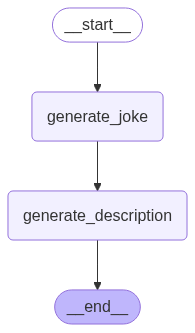

In [18]:


graph = StateGraph(JokeState)
graph.add_node("generate_joke", gen_joke)
graph.add_node("generate_description", gen_description)

graph.add_edge(START, "generate_joke")
graph.add_edge("generate_joke", "generate_description")
graph.add_edge( "generate_description", END)

checkpoint = MemorySaver()
workflow = graph.compile(checkpointer = checkpoint)
workflow




In [19]:
config = {"configurable" :{ "thread_id" : "1"}}
initial_state = {"topic" : "Women"}
final_state = workflow.invoke(input = initial_state, config=config)
final_state

{'topic': 'Women',
 'joke': "Why did the women's soccer team bring string to the game? \n\nIn case they wanted to tie the score!",
 'description': 'This is a light-hearted, pun-based joke playing on the double meaning of the word "tie." It\'s a family-friendly joke that relies on the association of string with the act of tying and the sporting term "tie" referring to a tied score. The humor comes from the unexpected connection between the two.'}

In [ ]:
final = workflow.get_state(config)

all_pointers = list(workflow.get_state_history(config))
# print("All checkpointers", all_pointers)
for pointer in all_pointers:
    print(f"State at {pointer}")

All checkpointers [StateSnapshot(values={'topic': 'Women', 'joke': "Why did the women's soccer team bring string to the game? \n\nIn case they wanted to tie the score!", 'description': 'This is a light-hearted, pun-based joke playing on the double meaning of the word "tie." It\'s a family-friendly joke that relies on the association of string with the act of tying and the sporting term "tie" referring to a tied score. The humor comes from the unexpected connection between the two.'}, next=(), config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f070b11-80f2-63d2-8002-84fe98ab2993'}}, metadata={'source': 'loop', 'step': 2, 'parents': {}, 'thread_id': '1'}, created_at='2025-08-03T21:30:36.365307+00:00', parent_config={'configurable': {'thread_id': '1', 'checkpoint_ns': '', 'checkpoint_id': '1f070b11-7866-6cae-8001-d25fca2e7377'}}, tasks=(), interrupts=()), StateSnapshot(values={'topic': 'Women', 'joke': "Why did the women's soccer team bring string to the ga